________________________

## M10-Evaluation

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

data_root = Path("/data/vserrano/cbc_pe_data")

history_path = data_root / "results" / "bbh_processed_4s_seobnrv4opt_snr10-25_n500_000" / (
    "bbh_processed_4s_seobnrv4opt_snr10-25_n500_000_"
    "SimpleCNN_ResidualDilated_"
    "M10_inputzscore_resdilated_emb64_d124_train100k_"
    "MSELoss_seed123_history.npz"
)

hist = np.load(history_path)
print(hist.files)

for k in hist.files:
    print(k, hist[k].shape, hist[k][:5] if hist[k].ndim > 0 else hist[k])

['train_loss', 'val_loss', 'train_time', 'val_time', 'epoch_time']
train_loss (101,) [0.64110001 0.50076482 0.45654271 0.37467219 0.31392465]
val_loss (101,) [0.52797947 0.49348796 0.45453753 0.31046701 0.26429765]
train_time (101,) [420.97878265 413.73676968 400.0039072  356.15587211 297.45551658]
val_time (101,) [ 92.22378802  97.12616873 102.97652149 101.00639367  51.90446353]
epoch_time (101,) [513.20257282 510.86294174 502.98043227 457.16226935 349.35998344]


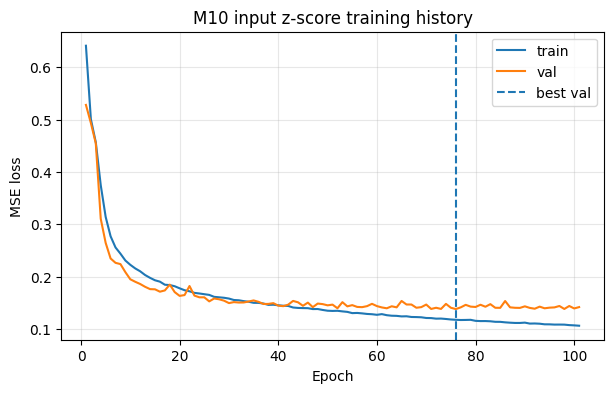

best epoch: 76
best val: 0.13785006055831908


In [2]:
train_loss = hist["train_loss"]
val_loss = hist["val_loss"]

epochs = np.arange(1, len(train_loss) + 1)

plt.figure(figsize=(7, 4))
plt.plot(epochs, train_loss, label="train")
plt.plot(epochs, val_loss, label="val")
plt.axvline(np.argmin(val_loss) + 1, linestyle="--", label="best val")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("M10 input z-score training history")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("best epoch:", np.argmin(val_loss) + 1)
print("best val:", float(np.min(val_loss)))

### Synthetic test

In [3]:
input_normalization = {
    "enabled": True,
    "mode": "per_sample_per_detector_zscore",
    "eps": 1e-6,
}

In [4]:
def zscore_per_sample_per_detector_np(X, eps=1e-6):
    """
    X shape:
        (N, C, T) or (C, T)
    """
    X = np.asarray(X, dtype=np.float32)

    if X.ndim == 2:
        mean = X.mean(axis=1, keepdims=True)
        std = X.std(axis=1, keepdims=True)
        return ((X - mean) / (std + eps)).astype(np.float32)

    if X.ndim == 3:
        mean = X.mean(axis=2, keepdims=True)
        std = X.std(axis=2, keepdims=True)
        return ((X - mean) / (std + eps)).astype(np.float32)

    raise ValueError(f"Expected X shape (C,T) or (N,C,T), got {X.shape}")

In [5]:
import h5py
import numpy as np
from pathlib import Path

data_root = Path("/data/vserrano/cbc_pe_data")

dataset_path = data_root / "processed" / "bbh_processed_4s_seobnrv4opt_snr10-25_n500_000" / "bbh_processed_4s_seobnrv4opt_snr10-25_n500_000.h5"

with h5py.File(dataset_path, "r") as f:
    X_batch = f["X"][:16].astype(np.float32)

print("X_batch shape:", X_batch.shape)
print("Before z-score")
print("means:", X_batch.mean(axis=2)[:5])
print("stds:", X_batch.std(axis=2)[:5])

X_check = zscore_per_sample_per_detector_np(X_batch)

print("\nAfter z-score")
print("means:", X_check.mean(axis=2)[:5])
print("stds:", X_check.std(axis=2)[:5])

print("\nSummary")
print("mean abs channel mean:", np.abs(X_check.mean(axis=2)).mean())
print("mean channel std:", X_check.std(axis=2).mean())

X_batch shape: (16, 3, 16384)
Before z-score
means: [[ 0.00524662  0.00229446 -0.00554621]
 [ 0.00581607  0.00784029 -0.01968945]
 [-0.00353929 -0.02061439  0.00413047]
 [ 0.02346002 -0.0150696  -0.00248801]
 [-0.00241953 -0.01210421 -0.00099267]]
stds: [[22.159405 21.877266 21.83404 ]
 [22.37847  23.03308  21.972206]
 [22.682234 22.592485 22.245266]
 [22.224697 22.118368 21.574474]
 [22.347122 21.585777 22.10776 ]]

After z-score
means: [[ 6.2282197e-09  9.3132257e-09  1.0244548e-08]
 [-2.0809239e-09 -2.4738256e-09 -8.1781764e-09]
 [ 1.1263182e-08  8.8475645e-09 -1.4028046e-08]
 [-1.0186341e-08 -1.7753337e-09 -1.6967533e-08]
 [ 6.1700121e-09 -5.8207661e-09 -1.7724233e-08]]
stds: [[0.9999999  0.9999999  0.9999999 ]
 [0.99999994 0.99999994 0.99999994]
 [0.9999999  0.99999994 0.9999999 ]
 [0.9999999  0.9999999  0.9999999 ]
 [0.99999994 0.99999994 0.9999999 ]]

Summary
mean abs channel mean: 6.6211214e-09
mean channel std: 0.99999994


In [6]:
import sys
import json
import numpy as np
from pathlib import Path
from torch.utils.data import DataLoader

project_root = Path("/afs/ciemat.es/user/v/vserrano/Desktop/gw/Gravitational-Waves-Lab/cbc_pe")
data_root = Path("/data/vserrano/cbc_pe_data")

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.models.dataset import HDF5RegressionDataset

config_path = project_root / "configs" / "experiments" / "train_100k_M10_inputzscore_resdilated_emb64_d124_bs256_seed123.json"

with open(config_path, "r") as f:
    cfg = json.load(f)

dataset_cfg = cfg["dataset"]
input_normalization_cfg = cfg["input_normalization"]

dataset_path = data_root / "processed" / "bbh_processed_4s_seobnrv4opt_snr10-25_n500_000" / dataset_cfg["dataset_file"]
split_path = data_root / "processed" / "bbh_processed_4s_seobnrv4opt_snr10-25_n500_000" / dataset_cfg["split_file"]
label_stats_path = data_root / "processed" / "bbh_processed_4s_seobnrv4opt_snr10-25_n500_000" / dataset_cfg["label_stats_file"]

splits = np.load(split_path)
stats = np.load(label_stats_path)

train_idx = splits["train_idx"]
y_mean = stats["y_mean"].astype(np.float32)
y_std = stats["y_std"].astype(np.float32)

ds = HDF5RegressionDataset(
    h5_path=dataset_path,
    indices=train_idx[:1024],
    y_mean=y_mean,
    y_std=y_std,
    input_normalization=input_normalization_cfg,
)

loader = DataLoader(
    ds,
    batch_size=16,
    shuffle=False,
    num_workers=0,
)

X_batch, y_batch = next(iter(loader))

print("X_batch:", X_batch.shape)
print("y_batch:", y_batch.shape)

means = X_batch.mean(dim=2)
stds = X_batch.std(dim=2, unbiased=False)

print("means first 5:")
print(means[:5])

print("stds first 5:")
print(stds[:5])

print("mean abs channel mean:", means.abs().mean().item())
print("mean channel std:", stds.mean().item())

ds.close()

X_batch: torch.Size([16, 3, 16384])
y_batch: torch.Size([16, 3])
means first 5:
tensor([[ 7.4506e-09,  1.8626e-09,  1.7229e-08],
        [ 1.3039e-08,  1.3737e-08,  1.6997e-08],
        [-1.5018e-08,  1.3970e-09, -3.7253e-09],
        [ 1.0477e-08, -7.4506e-09,  1.4203e-08],
        [ 9.7789e-09, -8.3819e-09,  6.8685e-09]])
stds first 5:
tensor([[1.0000, 1.0000, 1.0000],
        [1.0000, 1.0000, 1.0000],
        [1.0000, 1.0000, 1.0000],
        [1.0000, 1.0000, 1.0000],
        [1.0000, 1.0000, 1.0000]])
mean abs channel mean: 7.736161933280528e-09
mean channel std: 0.9999999403953552


In [7]:
from src.models.hdf5_batch_dataset import HDF5BatchIterableDataset
from torch.utils.data import DataLoader

batch_ds = HDF5BatchIterableDataset(
    h5_path=dataset_path,
    indices=train_idx[:2048],
    y_mean=y_mean,
    y_std=y_std,
    input_normalization=input_normalization_cfg,
    batch_size=16,
    drop_last=False,
    seed=123,
    shuffle_batches=False,
    shuffle_within_batch=False,
    max_slice_overread=4.0,
)

batch_loader = DataLoader(
    batch_ds,
    batch_size=None,
    num_workers=0,
)

X_batch_fast, y_batch_fast = next(iter(batch_loader))

print("X_batch_fast:", X_batch_fast.shape)
print("y_batch_fast:", y_batch_fast.shape)

means_fast = X_batch_fast.mean(dim=2)
stds_fast = X_batch_fast.std(dim=2, unbiased=False)

print("means first 5:")
print(means_fast[:5])

print("stds first 5:")
print(stds_fast[:5])

print("mean abs channel mean:", means_fast.abs().mean().item())
print("mean channel std:", stds_fast.mean().item())

X_batch_fast: torch.Size([16, 3, 16384])
y_batch_fast: torch.Size([16, 3])
means first 5:
tensor([[-4.4238e-09, -3.4925e-09, -7.3342e-09],
        [-2.4447e-09, -9.3132e-09,  1.1409e-08],
        [-3.2596e-09,  1.3562e-08, -1.1991e-08],
        [ 1.3039e-08, -2.6776e-09,  9.0804e-09],
        [ 1.1642e-09,  2.9104e-09, -7.5670e-09]])
stds first 5:
tensor([[1.0000, 1.0000, 1.0000],
        [1.0000, 1.0000, 1.0000],
        [1.0000, 1.0000, 1.0000],
        [1.0000, 1.0000, 1.0000],
        [1.0000, 1.0000, 1.0000]])
mean abs channel mean: 6.4659011478340744e-09
mean channel std: 0.9999999403953552


## Load M10 checkpoint

In [8]:
import torch
import importlib
from pathlib import Path

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

checkpoint_path = data_root / "models" / "checkpoints" / "bbh_processed_4s_seobnrv4opt_snr10-25_n500_000" / (
    "bbh_processed_4s_seobnrv4opt_snr10-25_n500_000_"
    "SimpleCNN_ResidualDilated_"
    "M10_inputzscore_resdilated_emb64_d124_train100k_"
    "MSELoss_seed123_checkpoint.pt"
)

print("checkpoint_path:", checkpoint_path)
print("exists:", checkpoint_path.exists())

ckpt = torch.load(checkpoint_path, map_location=device)

print("checkpoint keys:", ckpt.keys())
print("best epoch:", ckpt["epoch"])
print("best val loss:", ckpt["best_val_loss"])

model_config = ckpt["model_config"]
print("model_config keys:", model_config.keys())
print("input_normalization:", model_config.get("input_normalization", None))

device: cpu
checkpoint_path: /data/vserrano/cbc_pe_data/models/checkpoints/bbh_processed_4s_seobnrv4opt_snr10-25_n500_000/bbh_processed_4s_seobnrv4opt_snr10-25_n500_000_SimpleCNN_ResidualDilated_M10_inputzscore_resdilated_emb64_d124_train100k_MSELoss_seed123_checkpoint.pt
exists: True
checkpoint keys: dict_keys(['epoch', 'model_state_dict', 'optimizer_state_dict', 'train_loss', 'best_val_loss', 'y_mean', 'y_std', 'model_config', 'training_config', 'elapsed_seconds', 'history'])
best epoch: 76
best val loss: 0.13785006055831908
model_config keys: dict_keys(['architecture', 'class_name', 'dataset_id', 'dataset_format', 'dataset_path', 'split_path', 'label_stats_path', 'n_samples', 'n_detectors', 'signal_length', 'n_outputs', 'label_names', 'model_kwargs', 'normalization', 'input_normalization', 'loss', 'train_size', 'val_size', 'cal_size', 'test_size', 'training_seed', 'split_seed'])
input_normalization: {'enabled': True, 'mode': 'per_sample_per_detector_zscore', 'eps': 1e-06}


In [9]:
network_module = importlib.import_module("src.models.network")

model_class_name = model_config["class_name"]
model_kwargs = model_config["model_kwargs"]

model_class = getattr(network_module, model_class_name)

model_m10 = model_class(**model_kwargs).to(device)
model_m10.load_state_dict(ckpt["model_state_dict"])
model_m10.eval()

print(model_m10)

SimpleCNN_ResidualDilated(
  (block1): ConvBlock(
    (conv): Conv1d(3, 16, kernel_size=(16,), stride=(2,), padding=(8,))
    (group_norm): GroupNorm(8, 16, eps=1e-05, affine=True)
    (activation): LeakyReLU(negative_slope=0.01)
    (dropout): Dropout(p=0.05, inplace=False)
  )
  (block2): ConvBlock(
    (conv): Conv1d(16, 32, kernel_size=(16,), stride=(2,), padding=(8,))
    (group_norm): GroupNorm(8, 32, eps=1e-05, affine=True)
    (activation): LeakyReLU(negative_slope=0.01)
    (dropout): Dropout(p=0.05, inplace=False)
  )
  (block3): ConvBlock(
    (conv): Conv1d(32, 64, kernel_size=(16,), stride=(2,), padding=(8,))
    (group_norm): GroupNorm(8, 64, eps=1e-05, affine=True)
    (activation): LeakyReLU(negative_slope=0.01)
    (dropout): Dropout(p=0.05, inplace=False)
  )
  (residual_blocks): Sequential(
    (0): ResidualDilatedBlock(
      (conv1): Conv1d(64, 64, kernel_size=(7,), stride=(1,), padding=(3,))
      (norm1): GroupNorm(8, 64, eps=1e-05, affine=True)
      (activation

In [10]:
@torch.no_grad()
def predict_model(model, X, batch_size=512):
    """
    X shape: (N, C, T), already normalized if required.
    Returns:
        pred_std: standardized label predictions
        emb: latent embeddings if model returns them
    """
    model.eval()

    preds = []
    embs = []

    n = X.shape[0]

    for start in range(0, n, batch_size):
        stop = min(start + batch_size, n)

        xb = torch.from_numpy(X[start:stop].astype(np.float32)).to(device)

        out = model(xb)

        if isinstance(out, tuple):
            pred_b, emb_b = out
        else:
            pred_b = out
            emb_b = None

        preds.append(pred_b.detach().cpu().numpy())

        if emb_b is not None:
            embs.append(emb_b.detach().cpu().numpy())

    pred_std = np.concatenate(preds, axis=0)
    emb = np.concatenate(embs, axis=0) if embs else None

    return pred_std, emb


def inverse_label_standardization(y_std_values, y_mean, y_std):
    return y_std_values * y_std[None, :] + y_mean[None, :]

### Optional manual sanity check on 1k test samples

In [11]:
import h5py
import numpy as np
import pandas as pd

label_names = ["chirp_mass", "total_mass", "chi_eff"]

test_idx = splits["test_idx"].astype(np.int64)
print("test size:", len(test_idx))

# Para empezar, puedes evaluar todo el test de 20k.
# Si va lento, usa test_idx[:5000].
eval_idx = test_idx[:1000]

with h5py.File(dataset_path, "r") as f:
    X_test = f["X"][np.sort(eval_idx)].astype(np.float32)
    y_test_phys = f["y"][np.sort(eval_idx)].astype(np.float32)

print("Raw X_test:", X_test.shape, X_test.mean(), X_test.std())

X_test_z = zscore_per_sample_per_detector_np(X_test, eps=input_normalization_cfg["eps"])

print("Z-scored X_test:", X_test_z.shape)
print("mean abs channel mean:", np.abs(X_test_z.mean(axis=2)).mean())
print("mean channel std:", X_test_z.std(axis=2).mean())

pred_test_std, emb_test = predict_model(model_m10, X_test_z, batch_size=512)
pred_test_phys = inverse_label_standardization(pred_test_std, y_mean, y_std)

print("pred_test_phys:", pred_test_phys.shape)
print("emb_test:", None if emb_test is None else emb_test.shape)

test size: 20000
Raw X_test: (1000, 3, 16384) 0.00021865503 22.077839
Z-scored X_test: (1000, 3, 16384)
mean abs channel mean: 6.749183e-09
mean channel std: 1.0
pred_test_phys: (1000, 3)
emb_test: None


In [12]:
def regression_metrics(y_true, y_pred, label_names):
    rows = []

    for j, name in enumerate(label_names):
        err = y_pred[:, j] - y_true[:, j]

        mse = np.mean(err**2)
        rmse = np.sqrt(mse)
        mae = np.mean(np.abs(err))
        bias = np.mean(err)

        ss_res = np.sum(err**2)
        ss_tot = np.sum((y_true[:, j] - np.mean(y_true[:, j]))**2)
        r2 = 1.0 - ss_res / ss_tot

        rows.append({
            "label": name,
            "rmse": float(rmse),
            "mae": float(mae),
            "bias": float(bias),
            "r2": float(r2),
        })

    return pd.DataFrame(rows)

m10_test_metrics_df = regression_metrics(
    y_true=y_test_phys,
    y_pred=pred_test_phys,
    label_names=label_names,
)

display(m10_test_metrics_df)

,label,rmse,mae,bias,r2
0,chirp_mass,5.270136,3.688366,0.280516,0.888048
1,total_mass,10.048267,7.442403,0.143936,0.909879
2,chi_eff,0.191128,0.144720,0.016363,0.808329


In [13]:
outputs_dir = data_root / "results" / "m10_inputzscore_small"
outputs_dir.mkdir(parents=True, exist_ok=True)

m10_eval_path = outputs_dir / "m10_inputzscore_small_cal_test_predictions.npz"

np.savez_compressed(
    m10_eval_path,
    pred_test_std=pred_test_std,
    pred_test_phys=pred_test_phys,
    y_test_phys=y_test_phys,
    emb_test=emb_test,
    test_idx=eval_idx,
    y_mean=y_mean,
    y_std=y_std,
    label_names=np.array(label_names),
    input_normalization=np.array(str(input_normalization_cfg)),
)

print("Saved:", m10_eval_path)

Saved: /data/vserrano/cbc_pe_data/results/m10_inputzscore_small/m10_inputzscore_small_cal_test_predictions.npz


### Stress test de escala

In [14]:
GAINS = [
    (1.0, 1.0, 1.0),
    (1.0, 4.0, 7.0),
    (1.0, 1.0, 7.0),
    (1.0, 4.0, 1.0),
    (0.5, 2.0, 8.0),
]

stress_rows = []

# Usa un subconjunto para que sea rápido.
n_stress = min(5000, X_test.shape[0])
X_stress_base = X_test[:n_stress].copy()
y_stress_phys = y_test_phys[:n_stress].copy()

for gains in GAINS:
    gains_arr = np.array(gains, dtype=np.float32)[None, :, None]

    X_scaled_raw = X_stress_base * gains_arr

    # M10 contract: z-score after any raw scaling.
    X_scaled_z = zscore_per_sample_per_detector_np(
        X_scaled_raw,
        eps=input_normalization_cfg["eps"],
    )

    pred_scaled_std, _ = predict_model(model_m10, X_scaled_z, batch_size=512)
    pred_scaled_phys = inverse_label_standardization(pred_scaled_std, y_mean, y_std)

    metrics_df = regression_metrics(
        y_true=y_stress_phys,
        y_pred=pred_scaled_phys,
        label_names=label_names,
    )

    metrics_df["g_H1"] = gains[0]
    metrics_df["g_L1"] = gains[1]
    metrics_df["g_V1"] = gains[2]

    stress_rows.append(metrics_df)

m10_scale_stress_df = pd.concat(stress_rows, ignore_index=True)

display(
    m10_scale_stress_df.pivot_table(
        index=["g_H1", "g_L1", "g_V1"],
        columns="label",
        values="rmse",
        aggfunc="first",
    )
)

label            chi_eff  chirp_mass  total_mass
g_H1 g_L1 g_V1                                  
0.5  2.0  8.0   0.191128    5.270136   10.048268
1.0  1.0  1.0   0.191128    5.270136   10.048267
          7.0   0.191128    5.270136   10.048268
     4.0  1.0   0.191128    5.270136   10.048268
          7.0   0.191128    5.270136   10.048268

## Load VM-generated cal/test predictions

In [17]:
from pathlib import Path
import numpy as np

data_root = Path("/data/vserrano/cbc_pe_data")

pred_path = data_root / "results" / "bbh_processed_4s_seobnrv4opt_snr10-25_n500_000" / "m10_inputzscore_small_cal_test_predictions_embeddings.npz"

m10_pred = np.load(pred_path, allow_pickle=True)

print(m10_pred.files)

for key in m10_pred.files:
    arr = m10_pred[key]
    print(key, arr.shape, arr.dtype)

['y_mean', 'y_std', 'label_names', 'checkpoint_file', 'dataset_path', 'split_path', 'label_stats_path', 'model_config', 'input_normalization', 'available_splits', 'pred_cal', 'emb_cal', 'y_cal', 'idx_cal', 'pred_test', 'emb_test', 'y_test', 'idx_test']
y_mean (3,) float32
y_std (3,) float32
label_names (3,) <U10
checkpoint_file () <U196
dataset_path () <U86
split_path () <U142
label_stats_path () <U158
model_config () object
input_normalization () object
available_splits (2,) <U4
pred_cal (20000, 3) float32
emb_cal (20000, 64) float32
y_cal (20000, 3) float32
idx_cal (20000,) int64
pred_test (20000, 3) float32
emb_test (20000, 64) float32
y_test (20000, 3) float32
idx_test (20000,) int64


In [21]:
pred_test_std = m10_pred["pred_test"]
y_test_std = m10_pred["y_test"]

y_mean = m10_pred["y_mean"]
y_std = m10_pred["y_std"]
label_names = [str(x) for x in m10_pred["label_names"].tolist()]

pred_test_phys = pred_test_std * y_std[None, :] + y_mean[None, :]
y_test_phys = y_test_std * y_std[None, :] + y_mean[None, :]




display(regression_metrics(y_test_std, pred_test_std, label_names))

regression_metrics(y_test_phys, pred_test_phys, label_names)

,label,rmse,mae,bias,r2
0,chirp_mass,0.324498,0.225634,-0.000239,0.897037
1,total_mass,0.294086,0.217628,-0.012974,0.916050
2,chi_eff,0.472071,0.353965,0.039057,0.778215


,label,rmse,mae,bias,r2
0,chirp_mass,5.341313,3.713995,-0.003932,0.897037
1,total_mass,10.157347,7.516605,-0.448099,0.916050
2,chi_eff,0.208007,0.155966,0.017209,0.778215
